In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from transformers import AutoTokenizer

In [10]:
EXPANSION = 32

In [11]:
metrics = pd.read_csv(f"training_metrics/training_metrics_{EXPANSION}x.csv")

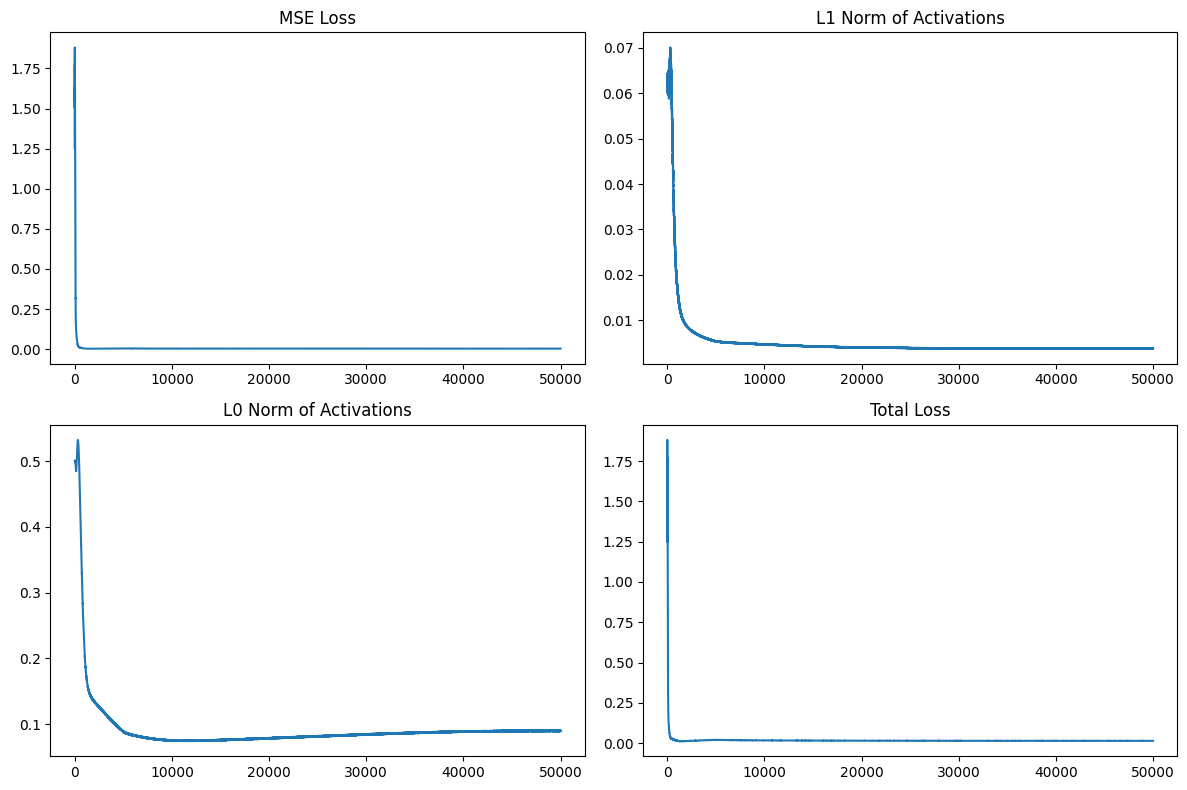

In [12]:
# plot the metrics
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [13]:
from sae import SparseAutoEncoder
from datasets import load_dataset

# Load tokenizer only (no need for the full model)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")

MODEL_PATH = f"saved_models/sae_model_{EXPANSION}x.pt"

# Load saved SAE
d = 512
m = d * EXPANSION
sae = SparseAutoEncoder(d=d, m=m)
sae.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
sae.eval()

# Load activations and process through SAE encoder in batches
# Full encoder output would be ~88GB, so we process in chunks
NUM_TEXTS = 50000
ACTIVATIONS_PATH = f"activations/activations_{NUM_TEXTS}.pt"

activations = torch.load(ACTIVATIONS_PATH, map_location="cpu")
n_tokens = activations.shape[0]
BATCH_SIZE = 4096

# We only need top-k per feature, so we track running top-k instead of storing everything
K = 20  # track top-K activating tokens per feature
top_vals = torch.zeros(m, K)
top_idxs = torch.full((m, K), -1, dtype=torch.long)

with torch.no_grad():
    for start in tqdm.trange(0, n_tokens, BATCH_SIZE):
        batch = activations[start:start + BATCH_SIZE]
        feat_acts = sae.encoder(batch)  # (batch, m)

        for j in range(feat_acts.shape[1]):
            combined_vals = torch.cat([top_vals[j], feat_acts[:, j]])
            combined_idxs = torch.cat([top_idxs[j], torch.arange(start, start + feat_acts.shape[0])])
            best = combined_vals.topk(K)
            top_vals[j] = best.values
            top_idxs[j] = combined_idxs[best.indices]

del activations

# Re-tokenize the same texts to get token strings
# TransformerLens prepends a BOS token per text, so we must do the same
dataset = load_dataset("openwebtext", split="train", streaming=True)
BOS = tokenizer.bos_token_id

all_tokens = []
all_contexts = []
for i, example in enumerate(tqdm.tqdm(dataset, total=NUM_TEXTS)):
    if i >= NUM_TEXTS:
        break
    text = example["text"][:512]
    token_ids = [BOS] + tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode(tid) for tid in token_ids]
    for t in tokens:
        all_tokens.append(t)
        all_contexts.append(text)

print(f"Total tokens: {len(all_tokens)}, activations: {n_tokens}")
assert len(all_tokens) == n_tokens, f"Mismatch! tokens={len(all_tokens)} vs activations={n_tokens}"
print(f"Tracked top-{K} activations for {m} features")

100%|██████████| 50000/50000 [00:27<00:00, 1788.60it/s]

Total tokens: 5884867, activations: 5884867
Tracked top-20 activations for 16384 features


In [14]:
def inspect_feature(feature_idx, k=10):
    k = min(k, K)
    vals = top_vals[feature_idx, :k]
    idxs = top_idxs[feature_idx, :k]

    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(vals, idxs):
        idx = idx.item()
        if idx < 0:
            break
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(2)
print()
inspect_feature(100)

Feature 2 — top 10 activating tokens:

  0.277  token=          ' to'   context: Rendlesham: Ministry of Defence officer reveals all about UFO claims

UFO expert
  0.276  token=          ' to'   context: Poll

Lawrence and Nugent threat make Derby trip a daunting one... but history f
  0.271  token=          ' to'   context: Plans to re-clad Landmark Heights, Lower Clapton, shelved in light of deadly Gre
  0.267  token=          ' to'   context: Mystery explosions that go bang in the night shake Highgate and Muswell Hill hom
  0.264  token=          ' to'   context: Dembele is now a key man under Pochettino as Spurs boss highlights balance betwe
  0.260  token=          ' to'   context: Rumour Mill: Norwich City close in on free agent Youssouf Mulumbu following WBA 
  0.257  token=        ' link'   context: Poll

Lawrence and Nugent threat make Derby trip a daunting one... but history f
  0.257  token=        ' link'   context: Plans to re-clad Landmark Heights, Lower Clapton, shelved 

In [15]:
# Features where the best activation is 0 are dead
alive_mask = top_vals[:, 0] > 0
dead_count = (~alive_mask).sum().item()

# Sort alive features by their top activation (lowest = sparsest)
alive_idxs = torch.where(alive_mask)[0]
sorted_order = top_vals[alive_idxs, 0].argsort()
sparsest_idxs = alive_idxs[sorted_order]

print(f"Dead features: {dead_count} / {m}")
print()
for idx in sparsest_idxs[:10]:
    idx = idx.item()
    # Count non-zero entries in top-K as a proxy
    n_active = (top_vals[idx] > 0).sum().item()
    print(f"Feature {idx}: top activation = {top_vals[idx, 0]:.4f} ({n_active}/{K} top slots active)")
    inspect_feature(idx, k=5)
    print()

Dead features: 1 / 16384

Feature 13973: top activation = 0.0001 (1/20 top slots active)
Feature 13973 — top 5 activating tokens:

  0.000  token=            'a'   context: Hundreds of thousands demonstrate across the country despite U-turn over transpo

Feature 3751: top activation = 0.0046 (3/20 top slots active)
Feature 3751 — top 5 activating tokens:

  0.005  token=        ' camp'   context: UNIVERSITY PARK, Pa. -- A parasitic fungus that must kill its ant hosts outside 
  0.003  token=          ' go'   context: (A) Alcian blue-stained colonic sections showing the mucus layer (arrows). Scale
  0.002  token=     ' tonight'   context: uugh, I feel like a goof and egotistical person 'advertising' my things, but

Pr

Feature 12840: top activation = 0.0090 (4/20 top slots active)
Feature 12840 — top 5 activating tokens:

  0.009  token=            ','   context: There's gold in that there dump. Or at least there's a genuine moon rock, now es
  0.002  token=         ' are'   context: Oz

In [16]:
# Rank features by strongest top activation
best_per_feature = top_vals[:, 0]
ranked = best_per_feature.argsort(descending=True)

for rank, idx in enumerate(ranked[:20]):
    idx = idx.item()
    print(f"=== Rank {rank+1}: Feature {idx} (top activation: {best_per_feature[idx]:.3f}) ===")
    inspect_feature(idx, k=5)
    print()

=== Rank 1: Feature 2049 (top activation: 165.700) ===
Feature 2049 — top 5 activating tokens:

  165.700  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  159.954  token=            '.'   context: Self-driving electric cars? Rad!! A Hyperloop train that can get you from New Yo
  159.242  token=            '.'   context: Fox News Channel pundits Greta Van Susteren and Erick Erickson have gone to war 
  159.054  token=            '.'   context: Poison Ivy is a 1985 American made-for-television romantic comedy film starring 
  159.015  token=            '.'   context: Solomon Islanders mourn death of Eroni Kumana who helped save life of John F. Ke

=== Rank 2: Feature 5285 (top activation: 31.624) ===
Feature 5285 — top 5 activating tokens:

  31.624  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  29.788  token=            '.'   context: In the second se

In [17]:
# Find the most "interpretable" features: ones where top-K tokens are consistent
# Score = fraction of top-K tokens that match the most common token
# Filter out single-char punctuation which dominates the max-activation ranking
from collections import Counter

BORING = {'.', "'", '-', '"', ',', '!', '?', ':', ';', '\n', ' ', ''}

scores = []
for feat_idx in range(m):
    idxs = top_idxs[feat_idx]
    valid = idxs[idxs >= 0]
    if len(valid) < 5:
        scores.append((feat_idx, 0.0, ""))
        continue
    tokens = [all_tokens[i.item()] for i in valid]
    counts = Counter(tokens)
    most_common_token, most_common_count = counts.most_common(1)[0]
    consistency = most_common_count / len(tokens)
    scores.append((feat_idx, consistency, most_common_token))

# Sort by consistency, filter out punctuation-only features
scores_filtered = [(idx, score, tok) for idx, score, tok in scores
                   if tok.strip() not in BORING and len(tok.strip()) > 0]
scores_filtered.sort(key=lambda x: -x[1])

print("Most consistent (interpretable) features:\n")
for feat_idx, consistency, top_token in scores_filtered[:30]:
    # if len(top_token) == 2:
    #     continue
    print(f"Feature {feat_idx}: {consistency:.0%} consistent, top token = {repr(top_token)}, max act = {top_vals[feat_idx, 0]:.3f}")
    inspect_feature(feat_idx, k=5)
    print()

Most consistent (interpretable) features:

Feature 0: 100% consistent, top token = ' feel', max act = 3.708
Feature 0 — top 5 activating tokens:

  3.708  token=        ' feel'   context: Pseudonym note: The author’s name has been changed to ensure anonymity. “Tirzah”
  3.700  token=        ' feel'   context: QPR boss Harry Redknapp has played down the comments he made following Saturday'
  3.676  token=        ' feel'   context: From Katherine Heigl movies to the Great Potty Disparity, writer Jerry Mahoney c
  3.662  token=        ' feel'   context: Jon Huntsman Sr. listens to secrets.

While the buzz right now is that Jon Hunts
  3.635  token=        ' feel'   context: It’s a familiar story for me: buy a game after it first dips into sale territory

Feature 3: 100% consistent, top token = ' turned', max act = 1.130
Feature 3 — top 5 activating tokens:

  1.130  token=      ' turned'   context: SAO PAULO (Reuters) - United States coach Juergen Klinsmann says he will now tur
  1.093  t

# W_dec Cosine Similarity Analysis

In [18]:
import numpy as np

# Normalize decoder weights
W_dec = sae.W_dec.data.clone()  # (m, d)
W_dec_normed = W_dec / W_dec.norm(dim=1, keepdim=True)

# Compute stats via chunked matmul — never allocate the full (m, m) matrix
CHUNK = 1024
max_sim = -1.0
sim_sum = 0.0

for i in range(0, m, CHUNK):
    chunk = W_dec_normed[i:i+CHUNK] @ W_dec_normed.T  # (CHUNK, m)
    # Zero out self-similarities
    for k in range(chunk.shape[0]):
        chunk[k, i + k] = 0.0
    max_sim = max(max_sim, chunk.max().item())
    sim_sum += chunk.sum().item()

print(f"Decoder weight matrix: {W_dec.shape}")
print(f"Max off-diagonal similarity: {max_sim:.4f}")
print(f"Mean off-diagonal similarity: {sim_sum / (m * (m - 1)):.4f}")

Decoder weight matrix: torch.Size([16384, 512])
Max off-diagonal similarity: 0.9775
Mean off-diagonal similarity: 0.0003


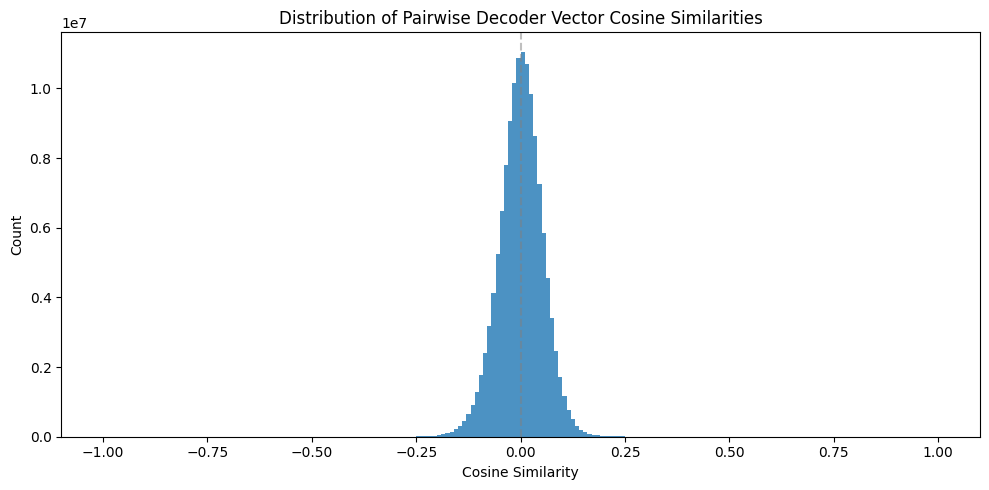

Pairs with |cos_sim| > 0.5: 3305
Pairs with |cos_sim| > 0.7: 748
Pairs with |cos_sim| > 0.9: 258


In [19]:
# Build histogram from chunks — never allocate full upper triangle
CHUNK = 1024
bins = np.linspace(-1, 1, 201)
hist_counts = np.zeros(len(bins) - 1, dtype=np.int64)
count_05 = 0
count_07 = 0
count_09 = 0

for i in range(0, m, CHUNK):
    chunk = W_dec_normed[i:i+CHUNK] @ W_dec_normed.T  # (CHUNK, m)
    # Only take upper triangle contributions: pairs (i+k, j) where j > i+k
    for k in range(chunk.shape[0]):
        row = chunk[k, i+k+1:].numpy()  # only j > i+k
        if len(row) == 0:
            continue
        hist_counts += np.histogram(row, bins=bins)[0]
        abs_row = np.abs(row)
        count_05 += (abs_row > 0.5).sum()
        count_07 += (abs_row > 0.7).sum()
        count_09 += (abs_row > 0.9).sum()

plt.figure(figsize=(10, 5))
plt.bar(bins[:-1], hist_counts, width=np.diff(bins), align='edge', alpha=0.8)
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Distribution of Pairwise Decoder Vector Cosine Similarities")
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Pairs with |cos_sim| > 0.5: {count_05}")
print(f"Pairs with |cos_sim| > 0.7: {count_07}")
print(f"Pairs with |cos_sim| > 0.9: {count_09}")

In [20]:
# Find top similar pairs using chunked topk — no full matrix sort
N_PAIRS = 20
TOP_PER_CHUNK = 200  # keep extra candidates for filtering

def top_token(feat_idx):
    idx = top_idxs[feat_idx, 0].item()
    return all_tokens[idx].strip() if idx >= 0 else ""

# Gather candidate pairs from chunks
CHUNK = 1024
candidates = []  # list of (sim_val, i, j)

for i in range(0, m, CHUNK):
    chunk = W_dec_normed[i:i+CHUNK] @ W_dec_normed.T  # (CHUNK, m)
    # Zero out self-similarities and lower triangle (avoid duplicates)
    for k in range(chunk.shape[0]):
        chunk[k, :i+k+1] = 0.0
    # Get top similarities from this chunk
    vals, idxs = chunk.flatten().topk(min(TOP_PER_CHUNK, chunk.numel()))
    for v, flat_idx in zip(vals, idxs):
        row = flat_idx.item() // m
        col = flat_idx.item() % m
        candidates.append((v.item(), i + row, col))

# Sort all candidates and display
candidates.sort(key=lambda x: -x[0])

print(f"Top {N_PAIRS} most similar feature pairs (filtered to meaningful tokens):\n")
seen = set()
count = 0
for sim_val, i, j in candidates:
    if count >= N_PAIRS:
        break
    pair = (min(i, j), max(i, j))
    if pair in seen:
        continue
    seen.add(pair)
    tok_i, tok_j = top_token(i), top_token(j)
    if len(tok_i) <= 1 or len(tok_j) <= 1:
        continue
    print(f"Features {i} & {j}: cosine sim = {sim_val:.4f}")
    inspect_feature(i, k=3)
    inspect_feature(j, k=3)
    print("-" * 80)
    count += 1

Top 20 most similar feature pairs (filtered to meaningful tokens):

Features 2266 & 12329: cosine sim = 0.9722
Feature 2266 — top 3 activating tokens:

  2.917  token=          ' in'   context: I should start off this review by declaring my undying love for the comedy troup
  2.882  token=          ' in'   context: On Friday afternoon, Wendy Lower, the author of Hitler’s Furies: German Women in
  2.851  token=          ' in'   context: Time well spent.

As usual, I would have to leave before I arrived. Memory threw
Feature 12329 — top 3 activating tokens:

  1.441  token=          ' in'   context: Some of you may not know this, because you're awesome and drive stick shift, but
  1.427  token=          ' in'   context: I think it was either Phog Allen or Ra’s al Ghul who said, “Every time a civiliz
  1.420  token=          ' in'   context: Carli Lloyd to sign with Manchester City, return to Dash in June

Carli Lloyd wi
--------------------------------------------------------------------

In [ ]:
# Cluster decoder vectors using KMeans (scales to any m, unlike hierarchical linkage)
from sklearn.cluster import MiniBatchKMeans
from scipy.cluster.hierarchy import linkage, dendrogram

N_CLUSTERS = 50
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=1024, random_state=42)
labels = kmeans.fit_predict(W_dec_normed.numpy())

# Show cluster sizes
cluster_sizes = np.bincount(labels, minlength=N_CLUSTERS)
print(f"Cluster sizes: min={cluster_sizes.min()}, max={cluster_sizes.max()}, "
      f"median={np.median(cluster_sizes):.0f}")

# Hierarchical clustering of the 50 cluster centroids (cheap: only 50x50)
centroids = kmeans.cluster_centers_
centroids_normed = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
centroid_cos_dist = 1 - centroids_normed @ centroids_normed.T
np.fill_diagonal(centroid_cos_dist, 0)
centroid_cos_dist = np.clip(centroid_cos_dist, 0, 2)

from scipy.spatial.distance import squareform
condensed = squareform(centroid_cos_dist)
Z = linkage(condensed, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8,
           labels=[f"C{i} ({cluster_sizes[i]})" for i in range(N_CLUSTERS)])
plt.title(f"Hierarchical Clustering of {N_CLUSTERS} KMeans Cluster Centroids")
plt.xlabel("Cluster (size)")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [29]:
def search_token(query, k=5):
    """Find features whose top-K activating tokens match the query.
    
    Matches any token containing the query string (case-insensitive).
    """
    results = []
    for feat_idx in range(m):
        idxs = top_idxs[feat_idx]
        valid = idxs[idxs >= 0]
        for rank, tok_idx in enumerate(valid[:K]):
            tok = all_tokens[tok_idx.item()]
            if query.lower() in tok.lower():
                results.append((feat_idx, rank, top_vals[feat_idx, rank].item(), tok))
                break  # only count best rank per feature

    results.sort(key=lambda x: x[1])  # sort by rank (0 = top token)
    print(f"Features with '{query}' in top-{K} tokens: {len(results)}\n")
    for feat_idx, rank, val, tok in results[:20]:
        print(f"  Feature {feat_idx}: rank={rank}, activation={val:.3f}, token={repr(tok)}")
    return results

# Example usage:
search_token("Houston")
print()

Features with 'Houston' in top-20 tokens: 11

  Feature 2301: rank=1, activation=0.235, token=' Houston'
  Feature 13945: rank=1, activation=0.271, token=' Houston'
  Feature 10272: rank=5, activation=0.262, token=' Houston'
  Feature 10679: rank=5, activation=0.294, token=' Houston'
  Feature 3749: rank=6, activation=0.235, token=' Houston'
  Feature 15639: rank=8, activation=1.318, token=' Houston'
  Feature 5169: rank=11, activation=0.255, token=' Houston'
  Feature 6667: rank=11, activation=0.303, token=' Houston'
  Feature 1379: rank=15, activation=0.580, token=' Houston'
  Feature 7760: rank=16, activation=0.205, token=' Houston'
  Feature 10931: rank=16, activation=0.837, token=' Houston'



In [30]:
inspect_feature(15639, k=10)

Feature 15639 — top 10 activating tokens:

  1.387  token=         'dong'   context: The Iron Fist Campaign was a compulsory sterilization program conducted in the s
  1.369  token=       ' Texas'   context: The outcome of the case against the man who allegedly ran online black market co
  1.343  token=   ' Francisco'   context: GI Bill's wording costs state's student vets EDUCATION

Paul Miller poses for a 
  1.340  token=        ' York'   context: The D.C. Forensic Sciences Department’s new glass-and-steel facility has been ho
  1.336  token=      ' Denver'   context: Heavyweight Bobby Lashley will finally get a chance at redemption when he faces 
  1.322  token=         'abad'   context: In Hyderabad, two videos have emerged of dogs being killed in cruel ways.

In th
  1.321  token=      ' Denver'   context: Not a fun Monday for Braves fans. First, their teams game gets snowed out in Den
  1.320  token=       ' Texas'   context: The past week all we’ve talked about is Sam Raimi writ